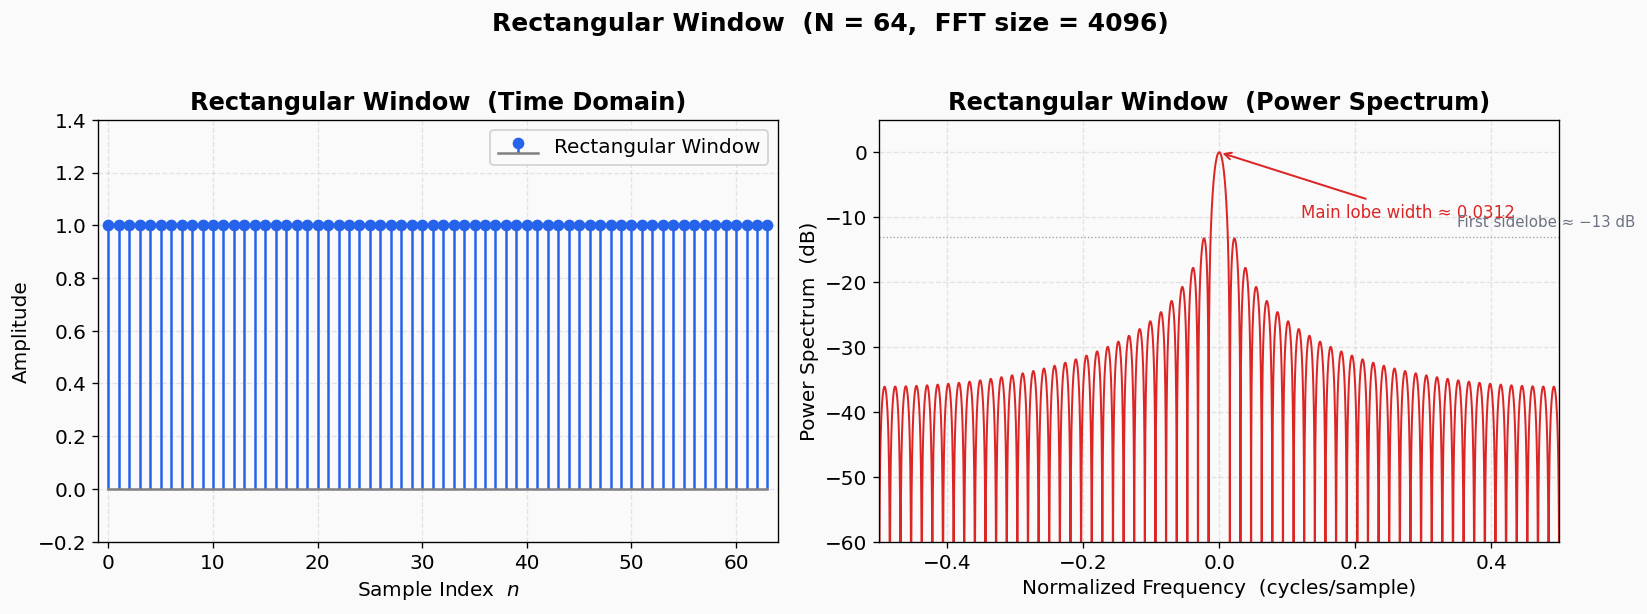

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ── 样式设置 ──────────────────────────────────────────────
rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.linewidth": 0.8,
    "figure.facecolor": "#fafafa",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# ── 参数 ─────────────────────────────────────────────────
N = 64                       # 窗口长度
NFFT = 4096                  # FFT 点数（补零，获得更平滑的频谱）

# ── 构造矩形窗 ───────────────────────────────────────────
rect_win = np.ones(N)

# ── 计算功率谱 ───────────────────────────────────────────
# 对窗函数做 FFT（补零到 NFFT）
spectrum = np.fft.fft(rect_win, n=NFFT)
# 功率谱 = |X(f)|^2
power_spectrum = np.abs(spectrum) ** 2
# 修复后：用 np.maximum 兜底，避免 log10(0)
power_spectrum_db = 10 * np.log10(np.maximum(power_spectrum / power_spectrum.max(), 1e-12))

# 频率轴，归一化到 [-0.5, 0.5)
freq = np.fft.fftfreq(NFFT)
freq_shifted = np.fft.fftshift(freq)
psd_shifted = np.fft.fftshift(power_spectrum_db)

# ── 绘图 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# ---- 子图 1：时域波形 ----
ax1 = axes[0]
n = np.arange(N)
ax1.stem(n, rect_win, linefmt="#2563eb", markerfmt="o",
         basefmt="gray", label="Rectangular Window")
ax1.set_xlabel("Sample Index  $n$")
ax1.set_ylabel("Amplitude")
ax1.set_title("Rectangular Window  (Time Domain)", fontweight="bold")
ax1.set_xlim(-1, N)
ax1.set_ylim(-0.2, 1.4)
ax1.legend(loc="upper right", framealpha=0.9)

# ---- 子图 2：功率谱 (dB) ----
ax2 = axes[1]
ax2.plot(freq_shifted, psd_shifted, color="#dc2626", linewidth=1.2)
ax2.set_xlabel("Normalized Frequency  (cycles/sample)")
ax2.set_ylabel("Power Spectrum  (dB)")
ax2.set_title("Rectangular Window  (Power Spectrum)", fontweight="bold")
ax2.set_xlim(-0.5, 0.5)
ax2.set_ylim(-60, 5)

# 标注主瓣宽度 = 2/N
main_lobe = 2 / N
ax2.annotate(
    f"Main lobe width ≈ {main_lobe:.4f}",
    xy=(0, 0), xytext=(0.12, -10),
    fontsize=10, color="#dc2626",
    arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.2),
)

# 标注第一旁瓣 ≈ -13 dB
ax2.axhline(y=-13, color="#9ca3af", linestyle=":", linewidth=0.8)
ax2.text(0.35, -11.5, "First sidelobe ≈ −13 dB",
         fontsize=9, color="#6b7280")

fig.suptitle(
    f"Rectangular Window  (N = {N},  FFT size = {NFFT})",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
# plt.savefig("rectangular_window_spectrum.png", bbox_inches="tight", dpi=150)
plt.show()


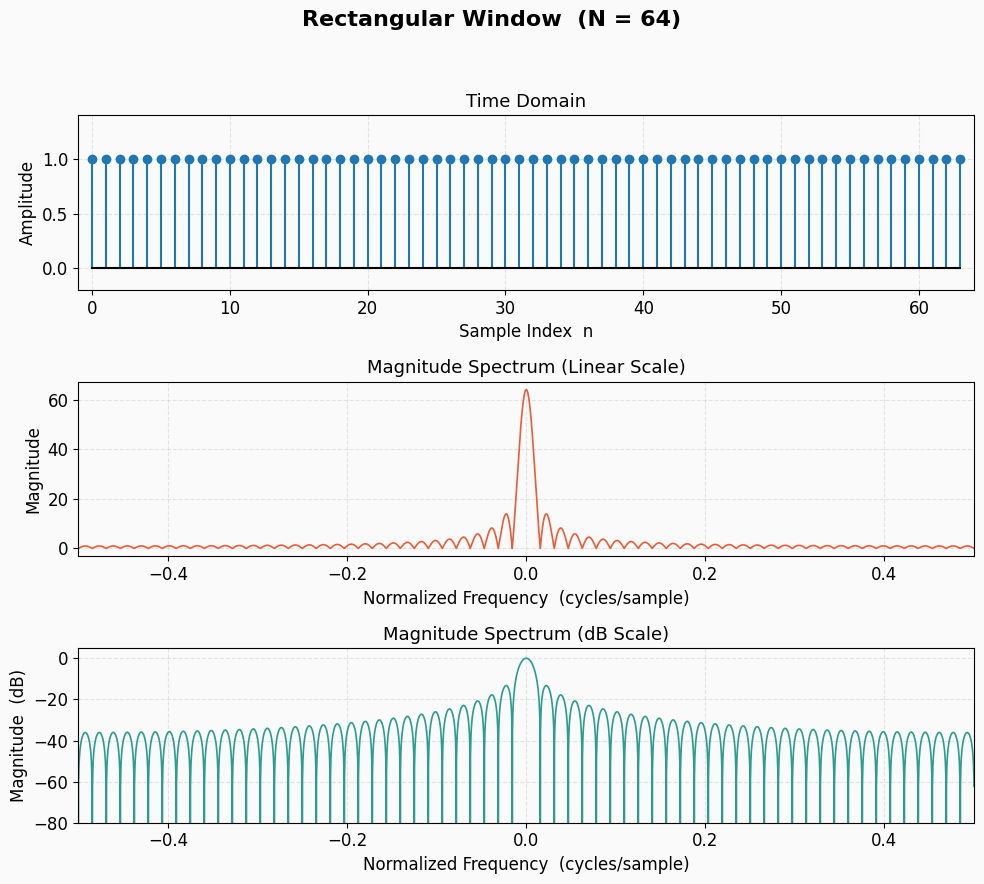

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── 参数设置 ──
N = 64                    # 窗口长度
nfft = 4096               # FFT 点数（补零以获得平滑频谱）

# ── 构造矩形窗 ──
n = np.arange(N)
rect_win = np.ones(N)

# ── 计算频谱 ──
spectrum = np.fft.fft(rect_win, nfft)
spectrum = np.fft.fftshift(spectrum)          # 零频移到中心
freq = np.linspace(-0.5, 0.5, nfft)          # 归一化频率

magnitude_lin = np.abs(spectrum)
magnitude_db  = 20 * np.log10(magnitude_lin / magnitude_lin.max() + 1e-12)

# ── 绘图 ──
fig, axes = plt.subplots(3, 1, figsize=(10, 9))
fig.suptitle(f'Rectangular Window  (N = {N})', fontsize=16, fontweight='bold')

# 1) 时域波形
ax = axes[0]
ax.stem(n, rect_win, linefmt='C0-', markerfmt='C0o', basefmt='k-')
ax.set_title('Time Domain', fontsize=13)
ax.set_xlabel('Sample Index  n')
ax.set_ylabel('Amplitude')
ax.set_xlim(-1, N)
ax.set_ylim(-0.2, 1.4)
ax.grid(True, alpha=0.3)

# 2) 线性幅度频谱
ax = axes[1]
ax.plot(freq, magnitude_lin, color='#e85d3a', linewidth=1.2)
ax.set_title('Magnitude Spectrum (Linear Scale)', fontsize=13)
ax.set_xlabel('Normalized Frequency  (cycles/sample)')
ax.set_ylabel('Magnitude')
ax.set_xlim(-0.5, 0.5)
ax.grid(True, alpha=0.3)

# 3) 对数幅度频谱 (dB)
ax = axes[2]
ax.plot(freq, magnitude_db, color='#2a9d8f', linewidth=1.2)
ax.set_title('Magnitude Spectrum (dB Scale)', fontsize=13)
ax.set_xlabel('Normalized Frequency  (cycles/sample)')
ax.set_ylabel('Magnitude  (dB)')
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-80, 5)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('rect_window_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()


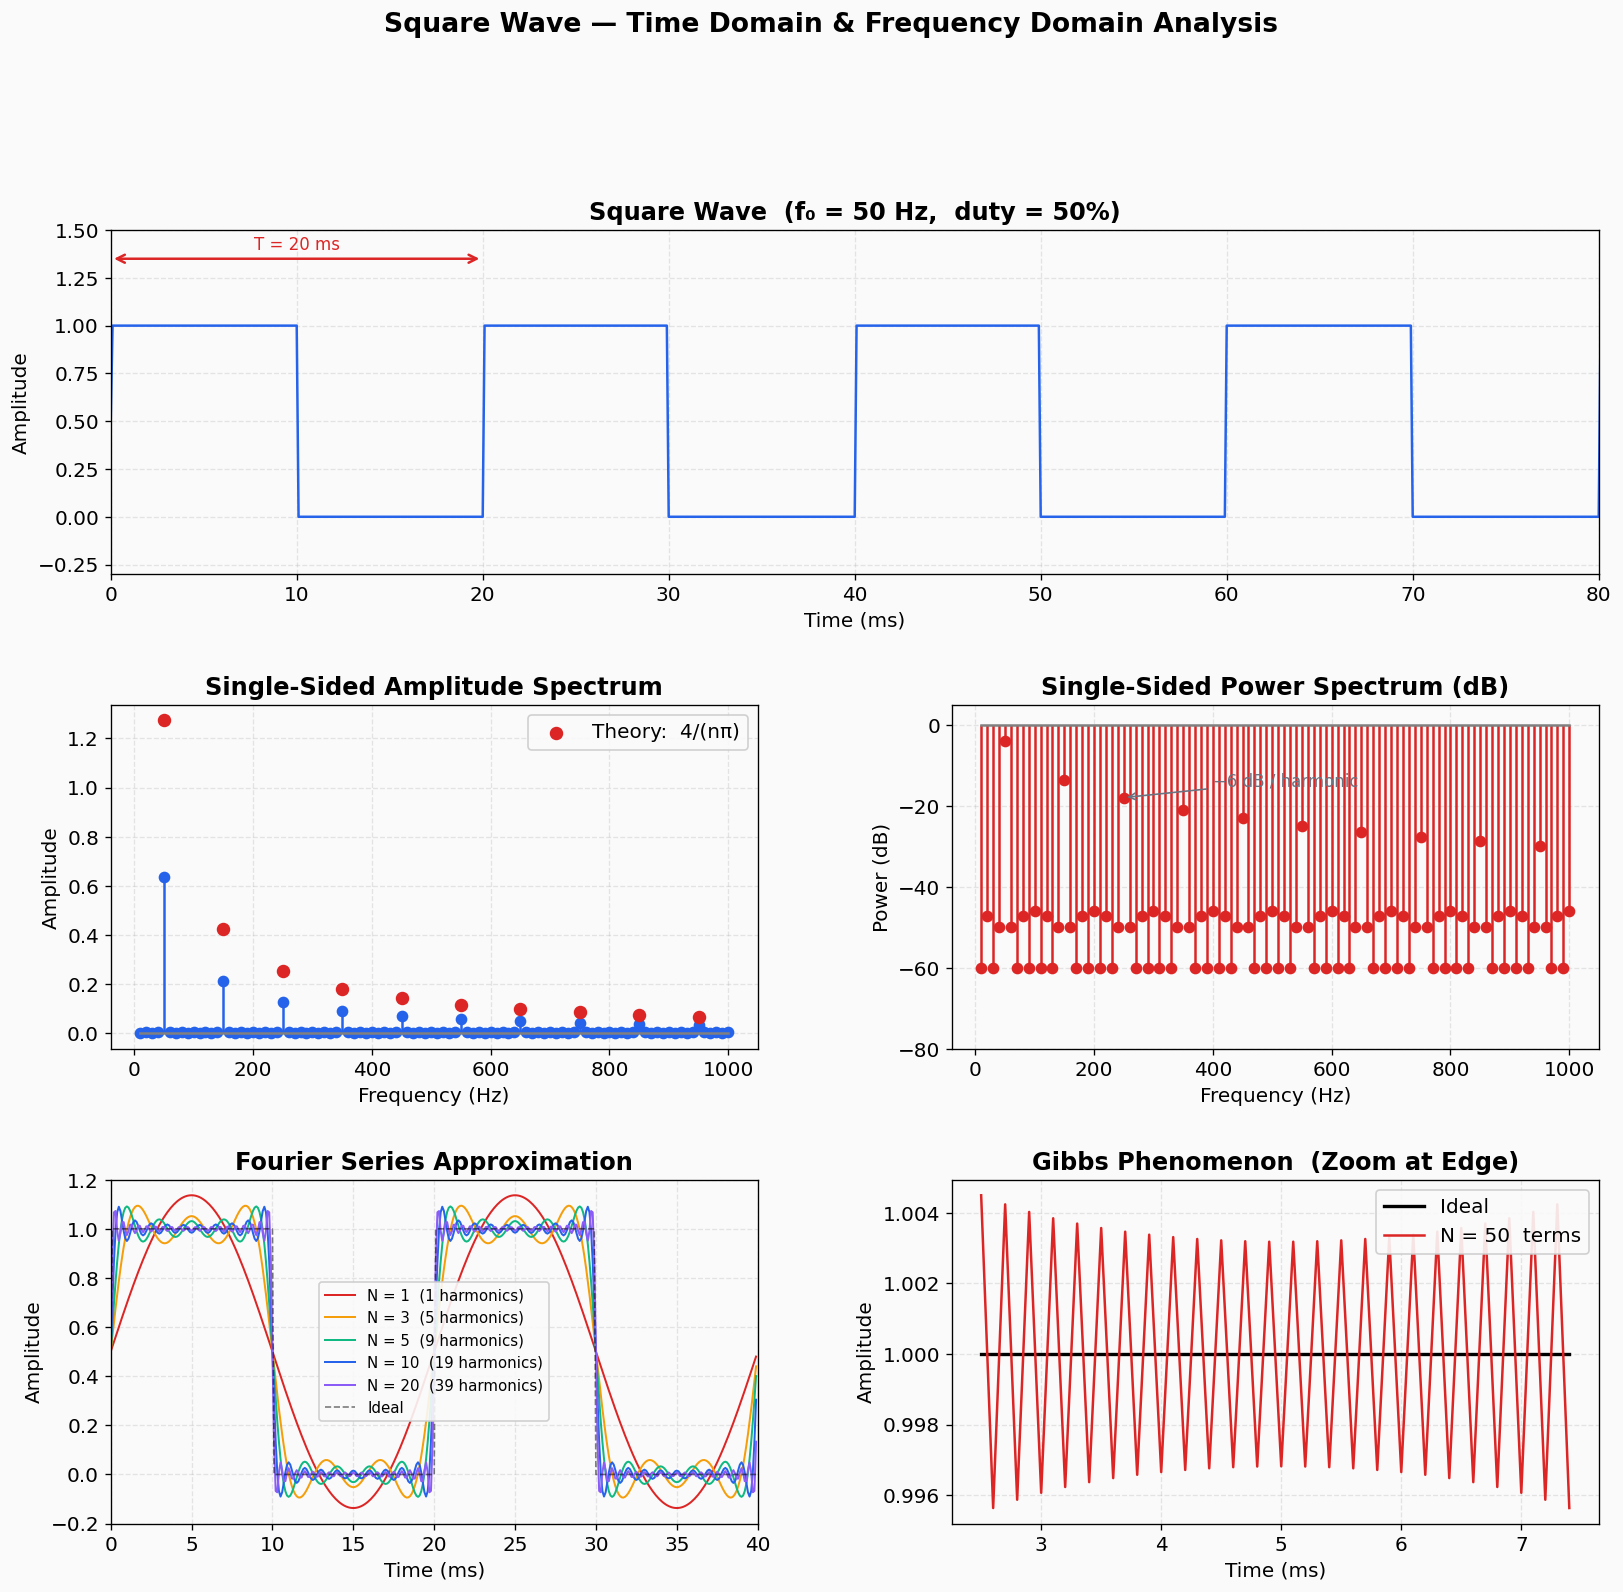

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ── 样式 ──────────────────────────────────────────────────
rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.linewidth": 0.8,
    "figure.facecolor": "#fafafa",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# ── 参数 ─────────────────────────────────────────────────
fs = 10000           # 采样率 (Hz)
f0 = 50              # 方波基频 (Hz)
T_total = 0.1        # 总时长 (s)
duty = 0.5           # 占空比 50%

# ── 生成方波 ─────────────────────────────────────────────
t = np.arange(0, T_total, 1 / fs)
square_wave = 0.5 * (1 + np.sign(np.sin(2 * np.pi * f0 * t)))  # 0 ~ 1
# 也可以用 scipy: from scipy.signal import square; square_wave = square(2*np.pi*f0*t, duty)

# ── FFT ──────────────────────────────────────────────────
N = len(square_wave)
spectrum = np.fft.fft(square_wave)
freqs = np.fft.fftfreq(N, d=1 / fs)

# 只取正频率部分
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]
mag_pos = np.abs(spectrum[pos_mask]) / N  # 归一化幅度

# 单边谱幅度 ×2（直流分量和奈奎斯特不翻倍）
mag_pos[1:-1] *= 2

# 功率谱 (dB)，加 1e-12 防止 log10(0)
power_db = 10 * np.log10(np.maximum(mag_pos ** 2, 1e-12))

# ── 傅里叶级数理论值：奇次谐波幅度 = 4/(nπ) ─────────────
harmonics = np.arange(1, 21, 2)              # 1,3,5,...,19
theory_amp = 4 / (harmonics * np.pi)         # 各奇次谐波幅度
theory_freq = harmonics * f0

# ── 傅里叶级数近似重建 ────────────────────────────────────
def fourier_square(t, f0, n_terms):
    """用前 n_terms 个奇次谐波叠加近似方波"""
    y = np.full_like(t, 0.5)  # 直流分量
    for k in range(1, n_terms + 1):
        n = 2 * k - 1  # 奇数
        y += (2 / (n * np.pi)) * np.sin(2 * np.pi * n * f0 * t)
    return y

# ── 绘图 ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14), dpi=120)
gs = fig.add_gridspec(3, 2, hspace=0.38, wspace=0.3)

# ---- 1. 时域方波 ----
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t * 1000, square_wave, color="#2563eb", linewidth=1.5)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Amplitude")
ax1.set_title("Square Wave  (f₀ = 50 Hz,  duty = 50%)", fontweight="bold")
ax1.set_xlim(0, 80)
ax1.set_ylim(-0.3, 1.5)

# 标注周期
T_ms = 1000 / f0
ax1.annotate("", xy=(T_ms, 1.35), xytext=(0, 1.35),
             arrowprops=dict(arrowstyle="<->", color="#dc2626", lw=1.5))
ax1.text(T_ms / 2, 1.40, f"T = {T_ms:.0f} ms", ha="center",
         fontsize=10, color="#dc2626")

# ---- 2. 幅度谱 (柱状图) ----
ax2 = fig.add_subplot(gs[1, 0])
# 只画到 1 kHz 以内
freq_limit = 1000
mask_bar = (freqs_pos > 0) & (freqs_pos <= freq_limit)
ax2.stem(freqs_pos[mask_bar], mag_pos[mask_bar],
         linefmt="#2563eb", markerfmt="o", basefmt="gray")
# 叠加理论值
ax2.scatter(theory_freq, theory_amp, color="#dc2626", s=50,
            zorder=5, label="Theory:  4/(nπ)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Amplitude")
ax2.set_title("Single-Sided Amplitude Spectrum", fontweight="bold")
ax2.legend(framealpha=0.9)

# ---- 3. 功率谱 (dB) ----
ax3 = fig.add_subplot(gs[1, 1])
mask_db = (freqs_pos > 0) & (freqs_pos <= freq_limit)
ax3.stem(freqs_pos[mask_db], power_db[mask_db],
         linefmt="#dc2626", markerfmt="o", basefmt="gray")
ax3.set_xlabel("Frequency (Hz)")
ax3.set_ylabel("Power (dB)")
ax3.set_title("Single-Sided Power Spectrum (dB)", fontweight="bold")
ax3.set_ylim(-80, 5)

# 标注谐波衰减斜率
ax3.annotate("−6 dB / harmonic", xy=(250, power_db[freqs_pos == 250][0]),
             xytext=(400, -15), fontsize=10, color="#6b7280",
             arrowprops=dict(arrowstyle="->", color="#6b7280"))

# ---- 4. 傅里叶级数逐次叠加 ----
ax4 = fig.add_subplot(gs[2, 0])
colors = ["#dc2626", "#f59e0b", "#10b981", "#2563eb", "#8b5cf6"]
for i, n_terms in enumerate([1, 3, 5, 10, 20]):
    y_approx = fourier_square(t, f0, n_terms)
    ax4.plot(t[:400] * 1000, y_approx[:400],
             color=colors[i], linewidth=1.2,
             label=f"N = {n_terms}  ({2*n_terms - 1} harmonics)")
ax4.plot(t[:400] * 1000, square_wave[:400],
         color="black", linewidth=1.0, linestyle="--", alpha=0.5, label="Ideal")
ax4.set_xlabel("Time (ms)")
ax4.set_ylabel("Amplitude")
ax4.set_title("Fourier Series Approximation", fontweight="bold")
ax4.legend(fontsize=9, framealpha=0.9)
ax4.set_xlim(0, 40)

# ---- 5. 吉布斯现象放大 ----
ax5 = fig.add_subplot(gs[2, 1])
y_50 = fourier_square(t, f0, 50)
# 找到第一个上升沿附近的索引
edge_idx = int(fs / (4 * f0))  # 1/4 周期处
win = int(fs / f0 / 8)         # 取一小段
sl = slice(edge_idx - win, edge_idx + win)
ax5.plot(t[sl] * 1000, square_wave[sl],
         color="black", linewidth=2, label="Ideal")
ax5.plot(t[sl] * 1000, y_50[sl],
         color="#dc2626", linewidth=1.5, label="N = 50  terms")
ax5.set_xlabel("Time (ms)")
ax5.set_ylabel("Amplitude")
ax5.set_title("Gibbs Phenomenon  (Zoom at Edge)", fontweight="bold")
ax5.legend(framealpha=0.9)

# 标注过冲 ≈ 9%
ax5.annotate("≈ 9% overshoot\n(Gibbs phenomenon)",
             xy=(t[edge_idx] * 1000, 1.09),
             xytext=(t[edge_idx] * 1000 + 0.3, 1.25),
             fontsize=10, color="#dc2626",
             arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.2))

fig.suptitle("Square Wave — Time Domain & Frequency Domain Analysis",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig("square_wave_spectrum.png", bbox_inches="tight", dpi=150)
plt.show()


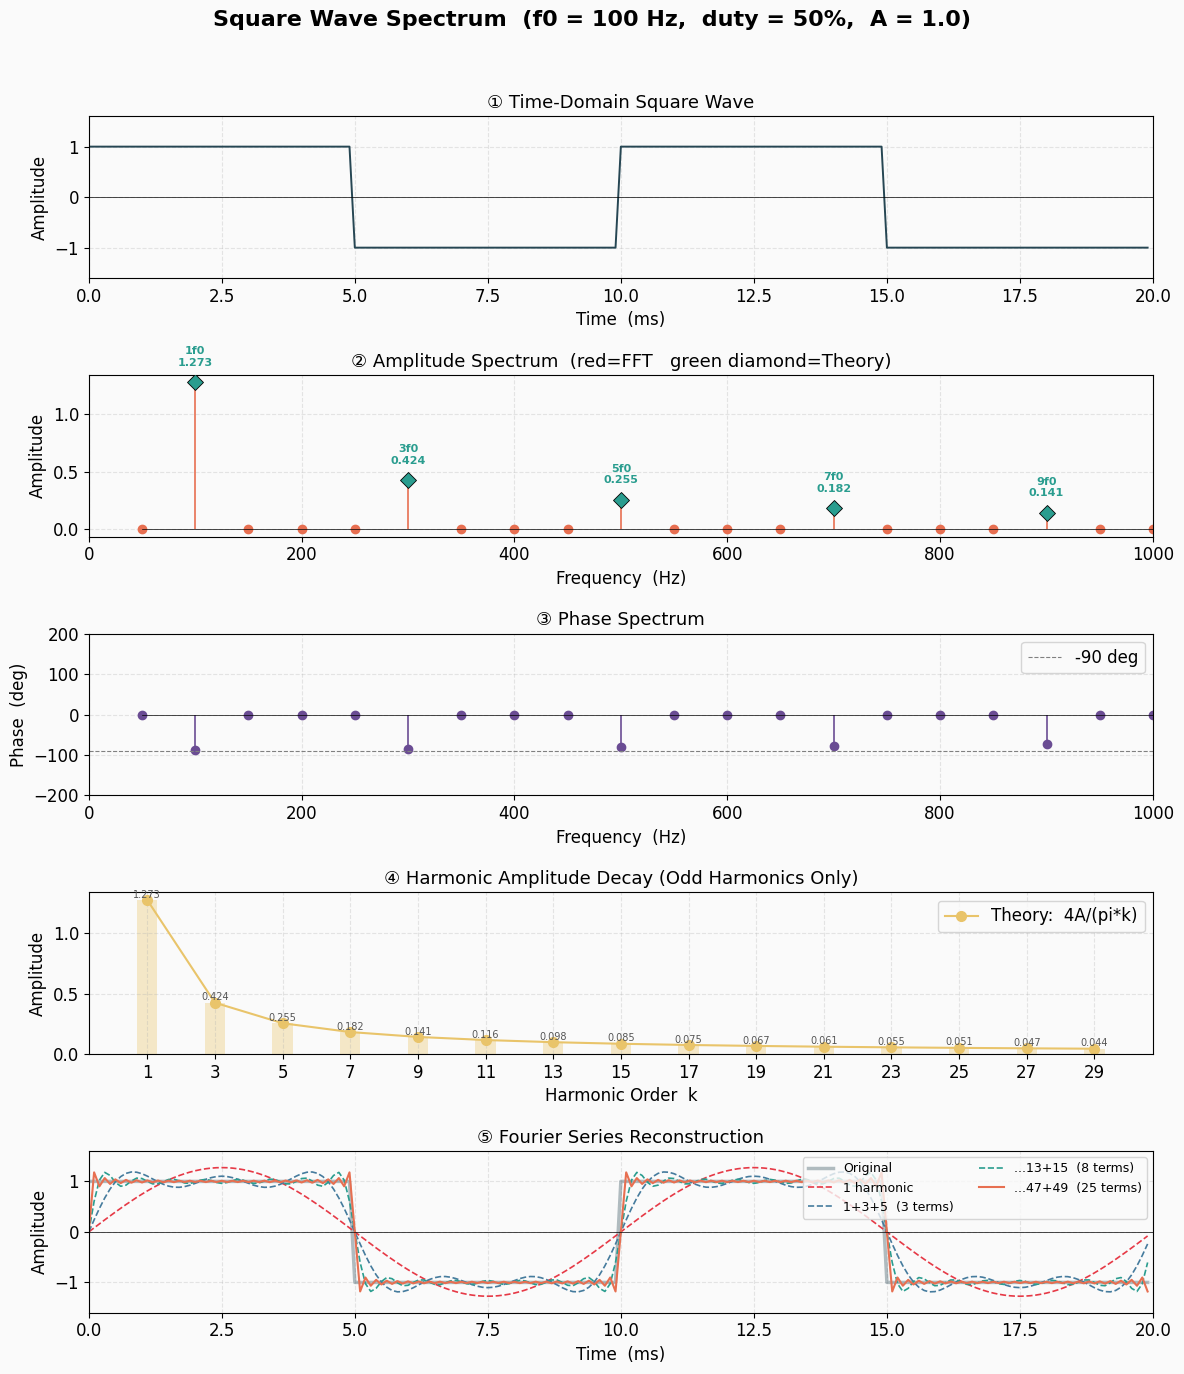

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════
#  参数设置
# ═══════════════════════════════════════════
fs    = 10000          # 采样率 (Hz)
T     = 0.02           # 信号时长 (s)  — 2 个周期
f0    = 100            # 方波基频 (Hz)
A     = 1.0            # 幅值
duty  = 50             # 占空比 (%)

# ═══════════════════════════════════════════
#  生成方波信号
# ═══════════════════════════════════════════
t = np.arange(0, T, 1 / fs)
square_wave = A * (2 * (t * f0 % 1 < duty / 100) - 1)

# ═══════════════════════════════════════════
#  FFT 计算频谱
# ═══════════════════════════════════════════
N = len(t)
X = np.fft.fft(square_wave) / N
freqs = np.fft.fftfreq(N, d=1 / fs)

pos_mask = freqs >= 0
freqs_pos   = freqs[pos_mask]
magnitude   = 2 * np.abs(X[pos_mask])
magnitude[0] /= 2
phase = np.angle(X[pos_mask], deg=True)

# ═══════════════════════════════════════════
#  傅里叶级数理论值
# ═══════════════════════════════════════════
max_harmonic = 15
harmonic_indices = np.arange(1, max_harmonic + 1, 2)
theory_mag = (4 * A / np.pi) / harmonic_indices

# ═══════════════════════════════════════════
#  谐波叠加合成
# ═══════════════════════════════════════════
def fourier_square(t, f0, A, n_terms):
    sig = np.zeros_like(t)
    for k in range(1, n_terms + 1, 2):
        sig += (4 * A / np.pi) * np.sin(2 * np.pi * k * f0 * t) / k
    return sig

recon_1  = fourier_square(t, f0, A, 1)
recon_5  = fourier_square(t, f0, A, 5)
recon_15 = fourier_square(t, f0, A, 15)
recon_49 = fourier_square(t, f0, A, 49)

# ═══════════════════════════════════════════
#  绘图  (5 幅子图)
# ═══════════════════════════════════════════
fig, axes = plt.subplots(5, 1, figsize=(12, 14))
fig.suptitle(
    f'Square Wave Spectrum  (f0 = {f0} Hz,  duty = {duty}%,  A = {A})',
    fontsize=16, fontweight='bold', y=0.98
)

# ── 颜色定义 ──
C_DARK   = '#264653'
C_RED    = '#e76f51'
C_GREEN  = '#2a9d8f'
C_PURPLE = '#6a4c93'
C_YELLOW = '#e9c46a'

# ── 1) 时域波形 ──
ax = axes[0]
ax.plot(t * 1000, square_wave, color=C_DARK, linewidth=1.4)
ax.set_title('① Time-Domain Square Wave', fontsize=13)
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Amplitude')
ax.set_ylim(-1.6, 1.6)
ax.set_xlim(0, T * 1000)
ax.axhline(0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)

# ── 2) 幅度谱 ──
ax = axes[1]
freq_limit = 1000
mask_bar = (freqs_pos > 0) & (freqs_pos <= freq_limit)

markerline, stemlines, baseline = ax.stem(
    freqs_pos[mask_bar], magnitude[mask_bar]
)
plt.setp(stemlines,  color=C_RED, linewidth=1.2)
plt.setp(markerline, color=C_RED, markersize=6)
plt.setp(baseline,   color='k',   linewidth=0.5)

# 标注理论值
for k in harmonic_indices:
    fk = k * f0
    if fk <= freq_limit:
        val = (4 * A / np.pi) / k
        ax.plot(fk, val, 'D', color=C_GREEN,
                markersize=8, markeredgecolor='k', markeredgewidth=0.6,
                zorder=5)
        ax.annotate(f'{k}f0\n{val:.3f}',
                    xy=(fk, val),
                    xytext=(0, 12), textcoords='offset points',
                    fontsize=8, ha='center', color=C_GREEN, fontweight='bold')

ax.set_title('② Amplitude Spectrum  (red=FFT   green diamond=Theory)', fontsize=13)
ax.set_xlabel('Frequency  (Hz)')
ax.set_ylabel('Amplitude')
ax.set_xlim(0, freq_limit)
ax.grid(True, alpha=0.3)

# ── 3) 相位谱 ──
ax = axes[2]
mask_phase = (freqs_pos > 0) & (freqs_pos <= freq_limit)

markerline, stemlines, baseline = ax.stem(
    freqs_pos[mask_phase], phase[mask_phase]
)
plt.setp(stemlines,  color=C_PURPLE, linewidth=1.2)
plt.setp(markerline, color=C_PURPLE, markersize=6)
plt.setp(baseline,   color='k',      linewidth=0.5)

ax.set_title('③ Phase Spectrum', fontsize=13)
ax.set_xlabel('Frequency  (Hz)')
ax.set_ylabel('Phase  (deg)')
ax.set_xlim(0, freq_limit)
ax.set_ylim(-200, 200)
ax.axhline(-90, color='gray', ls='--', lw=0.8, label='-90 deg')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# ── 4) 奇次谐波幅值衰减 ──
ax = axes[3]
k_range = np.arange(1, 31, 2)
theory_curve = (4 * A / np.pi) / k_range
ax.plot(k_range, theory_curve, 'o-', color=C_YELLOW,
        markersize=7, linewidth=1.5, label='Theory:  4A/(pi*k)')
ax.bar(k_range, theory_curve, width=0.6, color=C_YELLOW, alpha=0.35)
for k, v in zip(k_range, theory_curve):
    ax.text(k, v + 0.02, f'{v:.3f}', ha='center', fontsize=7, color='#555')
ax.set_title('④ Harmonic Amplitude Decay (Odd Harmonics Only)', fontsize=13)
ax.set_xlabel('Harmonic Order  k')
ax.set_ylabel('Amplitude')
ax.set_xticks(k_range)
ax.grid(True, alpha=0.3)
ax.legend()

# ── 5) 傅里叶级数合成逼近 ──
ax = axes[4]
t_ms = t * 1000
ax.plot(t_ms, square_wave, color=C_DARK,  lw=2.5, alpha=0.35, label='Original')
ax.plot(t_ms, recon_1,  '--', color='#e63946', lw=1.2, label='1 harmonic')
ax.plot(t_ms, recon_5,  '--', color='#457b9d', lw=1.2, label='1+3+5  (3 terms)')
ax.plot(t_ms, recon_15, '--', color=C_GREEN,   lw=1.2, label='...13+15  (8 terms)')
ax.plot(t_ms, recon_49, '-',  color=C_RED,     lw=1.5, label='...47+49  (25 terms)')
ax.set_title('⑤ Fourier Series Reconstruction', fontsize=13)
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Amplitude')
ax.set_xlim(0, T * 1000)
ax.set_ylim(-1.6, 1.6)
ax.axhline(0, color='k', linewidth=0.5)
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('square_wave_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
